# Monthly Mean Net Shortwave heat flux: ACCESS vs Papa
### As part of the flux components, this notebook produces a figure comparing the monthly mean net shortwave flux climatology of three different Access-om2 resolutions versus observational data from PAPA ocean station

In [2]:
import os
import re
import sys
import glob
import time
import intake
import numpy as np
import pandas as pd
import scipy as io
import xarray as xr
import matplotlib.dates as mdates

from mpi4py import MPI
from datetime import date, datetime, timedelta
from matplotlib import pyplot as plt
from dask.distributed import Client
from xarray.coding.times import CFDatetimeCoder

time_coder = CFDatetimeCoder(use_cftime=True)

In [3]:
client = Client()
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 1
Total threads: 1,Total memory: 32.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:45217,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:37747,Total threads: 1
Dashboard: /proxy/45575/status,Memory: 32.00 GiB
Nanny: tcp://127.0.0.1:46233,


In [4]:
print("Starting ACCESS-OM2 and Papa surface net shortwave flux analysis.")
sys.stdout.flush()

catalog = intake.cat.access_nri

# ---------------------------------------------------------------
# Date of interest
# ---------------------------------------------------------------
start_date = np.datetime64("2010-01-01")
end_date   = np.datetime64("2023-12-31")

# ---------------------------------------------------------------
# Variable and degrees of interest in ACCESS-OM2
# ---------------------------------------------------------------
var = "swflx"
experiments = [
    "1deg_jra55_iaf_omip2_cycle6",
    "025deg_jra55_iaf_omip2_cycle6",
    ["01deg_jra55v140_iaf_cycle4", "01deg_jra55v140_iaf_cycle4_jra55v150_extension"],
]

# ---------------------------------------------------------------
# PAPA
# ---------------------------------------------------------------
PAPA_DIR  = "/g/data/jk72/ob1561"
papa_file = os.path.join(PAPA_DIR, "swnet50n145w_hr.cdf")
papa_var  = "SWN_1495"   # NET SHORTWAVE RADIATION from the Papa file

# ---------------------------------------------------------------
# Region of interest (narrow 2° box around 50°N, 145°W)
# ---------------------------------------------------------------
region_lat = np.array([49, 51])          # yt_ocean, N
region_lon = np.array([213, 217])        # xt_ocean, E (213–217°E = 147–143°W)
region_lon = region_lon - 360            # -> [-147, -143] in degrees east
region     = [region_lat, region_lon]

print("Starting ACCESS-OM2 and Papa surface net shortwave flux analysis.")


Starting ACCESS-OM2 and Papa surface net shortwave flux analysis.
Starting ACCESS-OM2 and Papa surface net shortwave flux analysis.


In [5]:
#----------------------------------------------------------------------------------------------
# This section collects all the experiment / degrees / variable paths
#----------------------------------------------------------------------------------------------
print(f'Processing ACCESS {var} data...')
sys.stdout.flush()
    

path_dict = {}

catalogs = []

for exp in experiments:

    if isinstance(exp, list):  # both tenth degree + extention
        merged_name = exp[0]   
        path_dict[merged_name] = []
    
        for subexp in exp:
            filtered = catalog[subexp].search(
                variable=var,
                frequency='1mon',
                realm='ocean',
            )
            df = filtered.df
            df['start_date'] = pd.to_datetime(df['start_date'])
            df['end_date']   = pd.to_datetime(df['end_date'])
    
            df = df[
                (df['start_date'] >= np.datetime64("2010-01-01")) &
                (df['end_date']   <= np.datetime64("2023-12-31"))
            ]
    
            file_list = df['path'].tolist()
            path_dict[merged_name].extend(file_list)
    
        print(f"{merged_name}: {len(path_dict[merged_name])} files")
    
    else:  
        path_dict[exp] = []
        filtered = catalog[exp].search(
            variable=var,
            frequency='1mon',
            realm='ocean',
        )
        df = filtered.df
        df['start_date'] = pd.to_datetime(df['start_date'])
        df['end_date']   = pd.to_datetime(df['end_date'])
    
        df = df[
            (df['start_date'] >= np.datetime64("2010-01-01")) &
            (df['end_date']   <= np.datetime64("2023-12-31"))
        ]
    
        file_list = df['path'].tolist()
        path_dict[exp].extend(file_list)
    
        print(f"{exp}: {len(file_list)} files")

Processing ACCESS swflx data...
1deg_jra55_iaf_omip2_cycle6: 8 files
025deg_jra55_iaf_omip2_cycle6: 8 files
01deg_jra55v140_iaf_cycle4: 167 files


In [6]:
#----------------------------------------------------------------------------------------------
# Collect ACCESS data
#----------------------------------------------------------------------------------------------

exp_heat_flux = {} #dict for each deg

start = time.time()

exp_heat_flux = {}

experiments = [
    "1deg_jra55_iaf_omip2_cycle6",
    "025deg_jra55_iaf_omip2_cycle6",
    "01deg_jra55v140_iaf_cycle4"
]

for exp in experiments:
    print(f"Start collecting {var} {exp} data for ACCESS.")
    sys.stdout.flush()
    start = time.time()

    path_list = path_dict[exp]

    ds = xr.open_mfdataset(
        path_list,
        combine="nested",
        concat_dim="time",
        data_vars="minimal",
        coords="minimal",
        decode_timedelta=True
    )

    # Only sort time for tenth deg 
    if "01deg" in exp:
        ds = ds.sortby("time")

    # Slice region and time
    heat_flux = ds[var].sel(
        time=slice(start_date, end_date),
        yt_ocean=slice(region[0][0], region[0][1]),
        xt_ocean=slice(region[1][0], region[1][1])
    ).mean(dim=["yt_ocean", "xt_ocean"])

    ds.close()

    # Keep units
    units = heat_flux.attrs.get("units", "")
    heat_flux.attrs["units"] = units

    grp = heat_flux.groupby("time.month")
    monthly_mean = grp.mean("time", skipna=True)
    monthly_std  = grp.std("time", skipna=True)
    monthly_n    = grp.count("time")
    monthly_sem  = monthly_std / np.sqrt(monthly_n)
    
    exp_heat_flux[exp] = {
    "monthly_mean": monthly_mean,
    "monthly_sem": monthly_sem
}

    end = time.time()
    print(f"Finished collecting {var} data for ACCESS.")
    sys.stdout.flush()
    print(f"Execution time: {(end - start)/60:.2f} minutes")
    sys.stdout.flush()

Start collecting swflx 1deg_jra55_iaf_omip2_cycle6 data for ACCESS.
Finished collecting swflx data for ACCESS.
Execution time: 0.16 minutes
Start collecting swflx 025deg_jra55_iaf_omip2_cycle6 data for ACCESS.
Finished collecting swflx data for ACCESS.
Execution time: 0.05 minutes
Start collecting swflx 01deg_jra55v140_iaf_cycle4 data for ACCESS.
Finished collecting swflx data for ACCESS.
Execution time: 0.39 minutes


In [8]:
# --------------------------------------------------------------------------
# Read and collect data for Papa (shortwave)
# --------------------------------------------------------------------------

print(f"Processing Papa {papa_var} data...")
sys.stdout.flush()

start = time.time()

# Open Papa file
ds_papa = xr.open_dataset(papa_file)

# Extract shortwave flux variable
papa_flux = ds_papa[papa_var]

# ---- Robust masking of bad / fill values ----
# Fill / missing values are ~1e35, real SW flux should be O(10^2) W/m^2
papa_flux = papa_flux.where(np.isfinite(papa_flux))
papa_flux = papa_flux.where(np.abs(papa_flux) < 1e4)

# Restrict to the same time range as ACCESS
papa_flux = papa_flux.sel(time=slice(start_date, end_date))

# ---- Monthly mean + SEM (computed from the same samples) ----
grp = papa_flux.groupby("time.month")

papa_monthly_mean = grp.mean("time", skipna=True)
papa_monthly_std  = grp.std("time", skipna=True)
papa_monthly_n    = grp.count("time")
papa_monthly_sem  = papa_monthly_std / np.sqrt(papa_monthly_n)

# Reduce to 1D (month) by averaging over depth/lat/lon
papa_monthly_mean_1d = papa_monthly_mean.mean(dim=("depth", "lat", "lon"))
papa_monthly_sem_1d  = papa_monthly_sem.mean(dim=("depth", "lat", "lon"))

ds_papa.close()

print("\nPapa monthly climatology (after masking):")
print("min / max:", float(papa_monthly_mean_1d.min()), float(papa_monthly_mean_1d.max()))
print(papa_monthly_mean_1d)

end = time.time()
print(f"Finished collecting Papa {papa_var} data.")
print(f"Execution time: {(end - start)/60:.2f} minutes")
sys.stdout.flush()


Processing Papa SWN_1495 data...

Papa monthly climatology (after masking):
min / max: 20.822315216064453 168.7688751220703
<xarray.DataArray 'SWN_1495' (month: 12)> Size: 48B
array([ 26.057365,  52.167747,  97.836525, 146.4458  , 168.00337 ,
       168.76888 , 159.15884 , 140.45122 , 111.664   ,  67.58776 ,
        34.861336,  20.822315], dtype=float32)
Coordinates:
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Finished collecting Papa SWN_1495 data.
Execution time: 0.00 minutes


In [13]:
PAPA_DIR  = "/g/data/jk72/ob1561"
papa_file = os.path.join(PAPA_DIR, "swnet50n145w_hr.cdf")

ds = xr.open_dataset(papa_file)

print(ds)

sw = ds["SWN_1495"]

print("\nAttributes:", sw.attrs)
print("\nRaw min/max:", sw.min().item(), sw.max().item())
print("\nUnique values:", np.unique(sw.values[:200]))  # first 200 samples

ds.close()

<xarray.Dataset> Size: 2MB
Dimensions:   (time: 138523, depth: 1, lat: 1, lon: 1)
Coordinates:
  * time      (time) datetime64[ns] 1MB 2010-01-01 ... 2025-10-20T18:00:00
  * depth     (depth) float32 4B 0.0
  * lat       (lat) float32 4B 50.0
  * lon       (lon) float32 4B 215.0
Data variables:
    SWN_1495  (time, depth, lat, lon) float32 554kB ...
    QSW_5495  (time, depth, lat, lon) float32 554kB ...
Attributes:
    platform_code:                50n145w
    site_code:                    50n145w
    array:                        TAO/TRITON
    Request_for_acknowledgement:  If you use these data in publications or pr...
    Data_Source:                  OCS Project Office/NOAA/PMEL
    OCS:                          Dr. Meghan F. Cronin: Meghan.F.Cronin@noaa.gov
    File_info:                    Contact: Dai.C.McClurg@noaa.gov
    missing_value:                1e+35
    _FillValue:                   1e+35
    CREATION_DATE:                16:32  7-DEC-2025

Attributes: {'name': 'SWN',

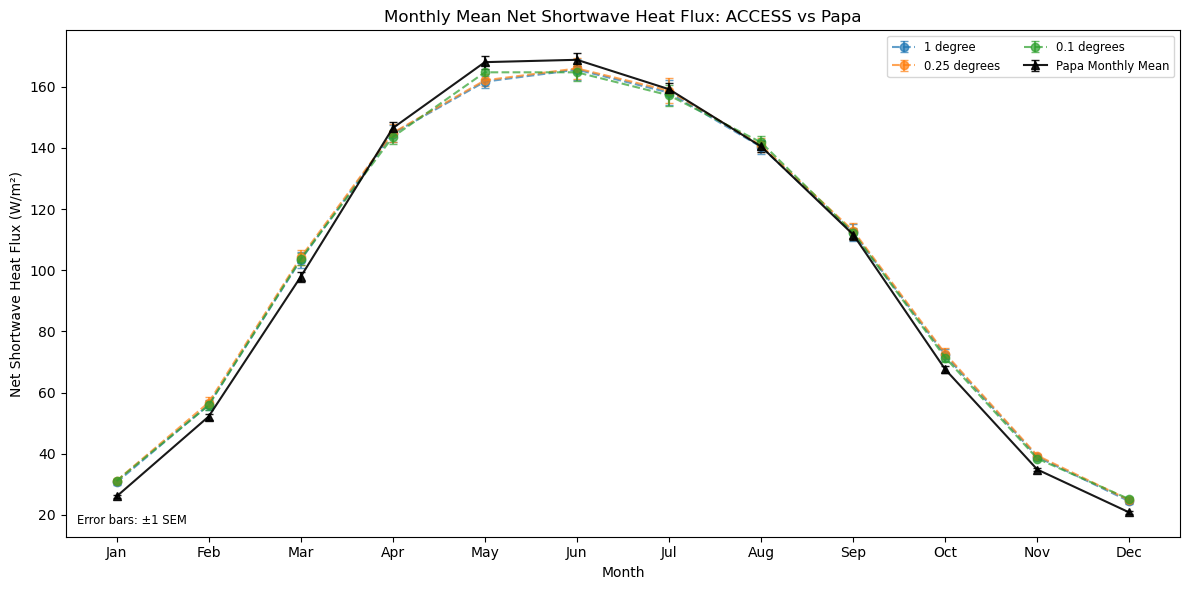

In [9]:
# --------------------------------------------------------------------------
# PLOT
# --------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 6))

exp_titles = {
    "1deg_jra55_iaf_omip2_cycle6": "1 degree",
    "025deg_jra55_iaf_omip2_cycle6": "0.25 degrees",
    "01deg_jra55v140_iaf_cycle4": "0.1 degrees",
}

# Plot ACCESS experiments (with ±1 SEM)
for exp_name, data_dict in exp_heat_flux.items():
    monthly_mean = data_dict["monthly_mean"]
    monthly_sem  = data_dict["monthly_sem"]
    label = exp_titles.get(exp_name, exp_name)

    ax.errorbar(
        monthly_mean["month"],
        monthly_mean.values,
        yerr=monthly_sem.values,
        marker="o",
        linestyle="--",
        alpha=0.7,
        capsize=3,
        label=label,
    )

# Plot Papa shortwave climatology (with ±1 SEM)
ax.errorbar(
    papa_monthly_mean_1d["month"],
    papa_monthly_mean_1d.values,
    yerr=papa_monthly_sem_1d.values,
    color="black",
    marker="^",
    linestyle="-",
    alpha=0.9,
    capsize=3,
    label="Papa Monthly Mean",
)

ax.set_xlabel("Month")
ax.set_ylabel("Net Shortwave Heat Flux (W/m²)")
ax.set_title("Monthly Mean Net Shortwave Heat Flux: ACCESS vs Papa")
ax.set_xticks(np.arange(1, 13))
ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])

ax.legend(ncol=2, fontsize="small", loc="best")

ax.text(
    0.01, 0.02,
    "Error bars: ±1 SEM",
    transform=ax.transAxes,
    fontsize="small",
    ha="left",
    va="bottom",
)

plt.tight_layout()
plt.show()


